# Sales Analysis

In [71]:
# Importing Libraries:

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Data Wrangling

In [10]:
#### a) Checking for the missing or incorrect entries
df= pd.read_csv('AusApparalSales4thQrt2020.csv')

# using isna() and sum() function to  get  the number missing or incorrect values with respect to column names

print(df.isnull().sum())
print(df.info())

# Using above methods we get no value errors in each column and reassuring with info() method

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB
None


In [14]:
#### b) Recommendations for treating missing and incorrect values:

# Replacing numerical columns with median() or mean()
df.fillna(df['Unit'].median(),inplace=True)


#                 OR          #


df.fillna(df['Sales'].mean(),inplace=True)

# Replacing categorical columns with mode

print(df.fillna(df.mode().iloc[0],inplace=True))

# or we can drop that specific row

df.dropna(axis=0, how='any',inplace=True)

None


In [29]:
#### c) Data Normalization using MinMaxScaler() to bound data between 0 and 1

sc= MinMaxScaler()

df['Unit']=sc.fit_transform(df[['Unit']])
df['Sales']=sc.fit_transform(df[['Sales']])
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,0.015873,0.015873


In [142]:
# d) Using groupby() funciton for Group based sales as well as State based sales

groupsales= df.groupby('Group')['Sales'].sum().reset_index()
print(groupsales)

# Identified that MEN contributed most of the sales
# So we can do target marketing strategies on MEN

statesales = df.groupby('State')['Sales'].sum().reset_index()



print('\n\n',statesales)


timesales= df.groupby('Time')['Sales'].sum().reset_index()
print('\n\n',timesales)
# from above function we got to know that people in VIC are buying almost double than the average and NT,TAS,
# WA are performing worst 
# so by expansion strategies we can optimize low-performing states

      Group       Sales
0      Kids  480.142857
1       Men  484.444444
2   Seniors  473.571429
3     Women  482.492063


   State       Sales
0   NSW  441.714286
1    NT  109.079365
2   QLD  177.888889
3    SA  339.412698
4   TAS  110.222222
5   VIC  635.968254
6    WA  106.365079


          Time       Sales
0   Afternoon  643.857143
1     Evening  631.666667
2     Morning  645.126984


## 2. Data Analysis

In [45]:
#### a) Performing descriptive statistical analysis on the data in the Sales and Unit

print('\nSales Statistics:\n')
print(df['Sales'].describe())

print('\nUnit Statistics:\n')
print(df['Unit'].describe())


Sales Statistics:

count    7560.000000
mean        0.254054
std         0.204784
min         0.000000
25%         0.095238
50%         0.190476
75%         0.380952
max         1.000000
Name: Sales, dtype: float64

Unit Statistics:

count    7560.000000
mean        0.254054
std         0.204784
min         0.000000
25%         0.095238
50%         0.190476
75%         0.380952
max         1.000000
Name: Unit, dtype: float64


In [58]:
#### b) Identifying the group with Highest sales and Lowest Sales

sales_group=  df.groupby('Group')['Sales'].sum()

# for group with highest sales
highest_sales_group = sales_group.idxmax()

# for group with lowest sales
lowest_sales_group= sales_group.idxmin()

print(f'Group with Highest Sales: {highest_sales_group}') 
print(f'Group with Lowest Sales: {lowest_sales_group}') 

Group with Highest Sales:  Men
Group with Lowest Sales:  Seniors


In [59]:
#### b) Identifying the group with Highest sales and Lowest Sales

sales_group=  df.groupby('Group')['Sales'].sum()

# for group with highest sales
highest_sales_group = sales_group.idxmax()

# for group with lowest sales
lowest_sales_group= sales_group.idxmin()

print(f'Group with Highest Sales: {highest_sales_group}') 
print(f'Group with Lowest Sales: {lowest_sales_group}') 

Group with Highest Sales:  Men
Group with Lowest Sales:  Seniors


In [70]:
# Generating weekly, monthly, and quarterly reports

df['Date']=pd.to_datetime(df['Date'], format= '%d-%b-%Y')
df["Week"] = df["Date"].dt.isocalendar().week
df['Month']= df['Date'].dt.month
df['Quarter']= df['Date'].dt.quarter


# Total sales according to week, month and quarter

weekly_report= df.groupby('Week')['Sales'].sum()
monthly_report=df.groupby('Month')['Sales'].sum()
quarterly_report= df.groupby('Quarter')['Sales'].sum()

print(f'Weekly Report:\n\n {weekly_report}')
print(f'Monthly Report:\n\n {monthly_report}')
print(f'Quarterly Report:\n\n {quarterly_report}')

Weekly Report:

 Week
40     84.857143
41    152.777778
42    150.476190
43    151.587302
44    122.460317
45    113.809524
46    115.761905
47    115.380952
48    117.698413
49    169.412698
50    181.492063
51    182.317460
52    183.047619
53     79.571429
Name: Sales, dtype: float64
Monthly Report:

 Month
10    645.650794
11    495.761905
12    779.238095
Name: Sales, dtype: float64
Quarterly Report:

 Quarter
4    1920.650794
Name: Sales, dtype: float64


## Data visualization

C:\Users\asus\AppData\Local\Temp\ipykernel_16024\4077574969.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Time',y='Sales',data=time_sales,palette='Set2')


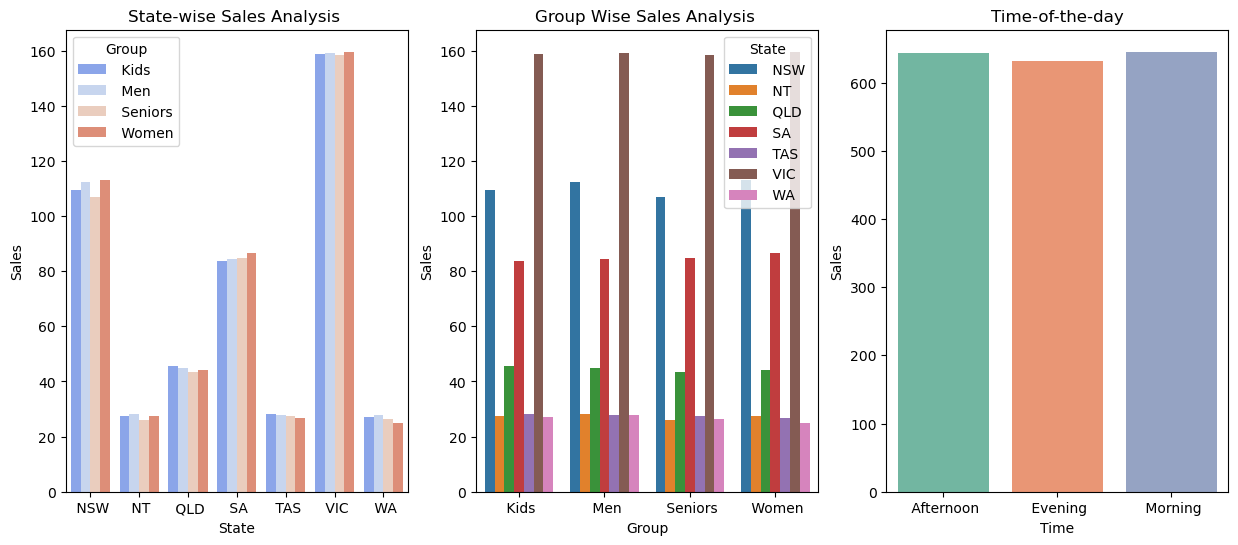

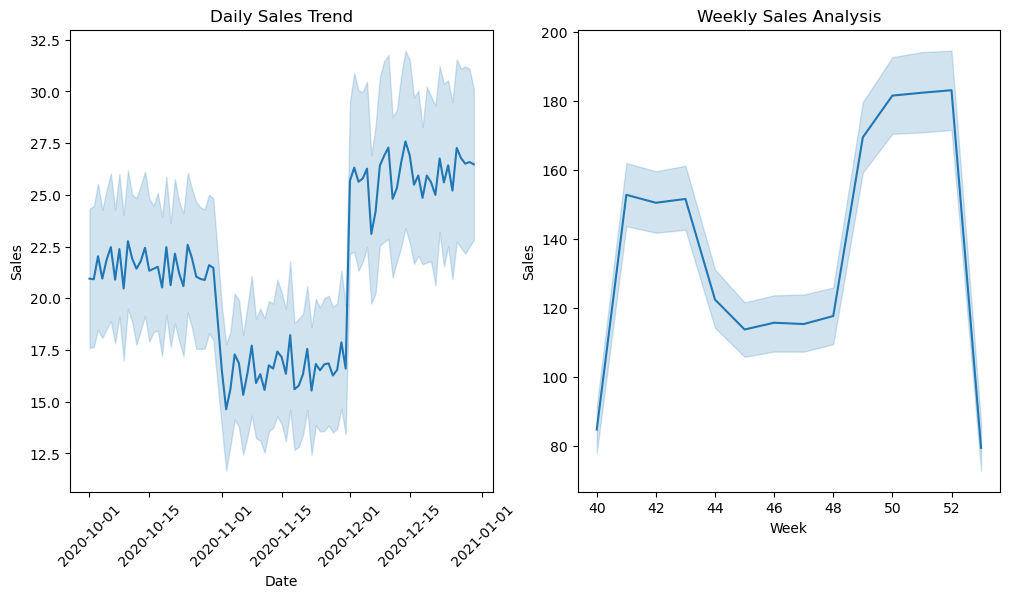

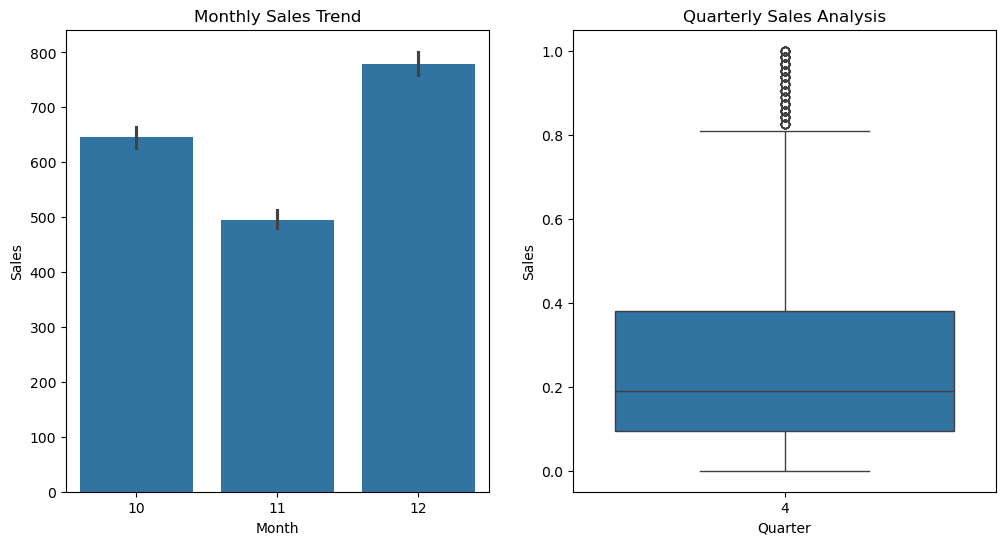

In [138]:
#### a) Dashboard for the head of sales and marketing

## state-wise sales analysis for different demographic groups
state_group_sales = df.groupby(['State','Group'])['Sales'].sum().reset_index()

plt.figure( figsize=(15,6))

plt.subplot(1,3,1)
sns.barplot(state_group_sales,x='State',y='Sales',hue='Group',palette='coolwarm')
plt.title('State-wise Sales Analysis ')

## Group-wise  analysis across different states
plt.subplot(1,3,2)

sns.barplot(state_group_sales,x='Group',y='Sales',hue='State')
plt.title('Group Wise Sales Analysis ')


# Time of the day sales
time_sales= df.groupby('Time')['Sales'].sum().reset_index()
plt.subplot(1,3,3)
sns.barplot(x='Time',y='Sales',data=time_sales,palette='Set2')
plt.title('Time-of-the-day')
plt.show()

plt.figure(figsize=(12, 6))

plt.subplot(1,2,1)
sns.lineplot(x="Date", y="Sales", data=df, estimator=sum)
plt.title("Daily Sales Trend")
plt.xticks(rotation=45)


plt.subplot(1,2,2)
sns.lineplot(x="Week", y="Sales", data=df, estimator=sum)
plt.title("Weekly Sales Analysis")
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
sns.barplot(x="Month", y="Sales", data=df, estimator=sum)
plt.title("Monthly Sales Trend")


plt.subplot(1,2,2)
sns.boxplot(x="Quarter", y="Sales", data=df)
plt.title("Quarterly Sales Analysis")
plt.show()


#### c.) Why I am using seaborn:


* Statistical Analysis: Seaborn provides built-in support for box plots, distribution plots, and categorical plots, making it ideal for this dataset.
* Better Readability: It applies advanced styling and color palettes, improving visualization aesthetics.
* Integration with Pandas: Works seamlessly with Pandas DataFrames, simplifying data analysis and visualization.

# Sales Analysis Report

## **1. Data Wrangling**
- The dataset was cleaned by handling missing values.
- Normalization was applied to scale the Sales and Unit data.

## **2. Data Analysis**
- **Highest Sales Group:** Men  
- **Lowest Sales Group:** Seniors  
- **State with Highest Revenue:** NSW  
- **Peak Sales Time:** Morning  

## **3. Data Visualization**
The following charts were created:
1. **State-wise sales for different demographic groups**
2. **Group-wise distribution across various states**
3. **Sales by time of the day**
4. **Day, Weekly, Monthly, Quarterly**

### **4. Recommendations**
- Focus marketing efforts on **low-performing states**.
- Create **promotions for seniors** since they contribute the least to sales.
- **Increase staffing in the Morning** when sales peak.